# Signal Respirometry — Project Setup

This notebook bootstraps a standard structure for data analysis:

- `data/` — raw, processed, and external data
- `figures/` — generated plots and exports
- `video/` — raw videos and derived clips
- `notebooks/` — analysis notebooks (this file)

It also performs a quick environment check, ensures directories exist, and creates a demo plot in `figures/`.

In [1]:
# Set Project paths
from pathlib import Path
ROOT = Path('..').resolve()  # This notebook lives in notebooks/
DATA_DIR = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'
VIDEO_DIR = ROOT / 'video'
NOTEBOOKS_DIR = ROOT / 'notebooks'

# Optional sub-structure under data/
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
EXTERNAL_DIR = DATA_DIR / 'external'

for p in [DATA_DIR, FIGURES_DIR, VIDEO_DIR, NOTEBOOKS_DIR, RAW_DIR, PROCESSED_DIR, EXTERNAL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('ROOT      =', ROOT)
print('DATA_DIR  =', DATA_DIR)
print('FIGURES   =', FIGURES_DIR)
print('VIDEO     =', VIDEO_DIR)

ROOT      = /Users/oakley/Documents/GitHub/signal_respirometry
DATA_DIR  = /Users/oakley/Documents/GitHub/signal_respirometry/data
FIGURES   = /Users/oakley/Documents/GitHub/signal_respirometry/figures
VIDEO     = /Users/oakley/Documents/GitHub/signal_respirometry/video


## Quantification: detect pulses and blue streaks as contours

We start a simple contour-based detector that thresholds the blue channel, filters small areas, and writes centroids per frame to CSV. 

## Per-video interactive workflow (recommended)

- For each video:
  1) Set `video_name` below and (optionally) load saved params for that video.
  2) Run the extraction cell to regenerate the CSV.
  3) Use the preview/ROI cells to tune thresholds and draw ROIs.
  4) Use the final ROI-only viewer to sanity-check.
  5) Save the tuned parameters for this video (so you can recall them later).

.
Alternative: You can duplicate this notebook (one per video) if you prefer keeping everything isolated; all outputs are already keyed by video stem.

In [2]:
video_name = "GX010067_2025Nov12.MP4"

# Toggle ROI re-selection when running end-to-end
rerun_roi = False  # False = reuse existing ROI JSON if present; True = force interactive ROI selection
print('rerun_roi =', rerun_roi)

rerun_roi = False


In [3]:
# Set current video and (optionally) load saved params for it
from pathlib import Path
import json

# Ensure paths
ROOT = Path('..').resolve()
VIDEO_DIR = ROOT / 'video'
DATA_DIR = ROOT / 'data'
CONFIG_DIR = DATA_DIR / 'config'
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# Pick a default video if none set yet
videos = sorted([p.name for p in VIDEO_DIR.iterdir() if p.is_file() and p.suffix.lower() in {'.mp4','.mov','.mkv','.avi','.m4v'}])
try:
    video_name
except NameError:
    video_name = videos[0] if videos else 'GX010063.MP4'

print('Current video_name =', video_name)

# Try to load saved params for this video (if present)
params_path = CONFIG_DIR / f"{Path(video_name).stem}_analysis.json"
if params_path.exists():
    with open(params_path, 'r') as f:
        saved = json.load(f)
    # Apply known params if defined in saved JSON
    analyze_scale = float(saved.get('analyze_scale', globals().get('analyze_scale', 0.5)))
    blue_thresh   = saved.get('blue_thresh', globals().get('blue_thresh', 60))
    blur_ksize    = int(saved.get('blur_ksize', globals().get('blur_ksize', 0)))
    min_area      = float(saved.get('min_area', globals().get('min_area', 1.5)))
    use_bminusg   = bool(saved.get('use_bminusg', globals().get('use_bminusg', True)))
    seconds_per_frame = float(saved.get('seconds_per_frame', globals().get('seconds_per_frame', 30.0)))
    # Persistence filter params
    enable_persistence_filter = bool(saved.get('enable_persistence_filter', globals().get('enable_persistence_filter', True)))
    persistence_link_radius_px = float(saved.get('persistence_link_radius_px', globals().get('persistence_link_radius_px', 8.0)))
    max_track_duration_s = float(saved.get('max_track_duration_s', globals().get('max_track_duration_s', 50.0)))
    print('Loaded saved parameters from', params_path)
else:
    print('No saved parameters found for this video; using current defaults.')

# Show the parameters currently in effect (using variables if set, else defaults)
effective = {
    'analyze_scale': float(globals().get('analyze_scale', 0.5)),
    'blue_thresh': globals().get('blue_thresh', 60),
    'blur_ksize': int(globals().get('blur_ksize', 0)),
    'min_area': float(globals().get('min_area', 1.5)),
    'use_bminusg': bool(globals().get('use_bminusg', True)),
    'seconds_per_frame': float(globals().get('seconds_per_frame', 30.0)),
    # Persistence filter params
    'enable_persistence_filter': bool(globals().get('enable_persistence_filter', True)),
    'persistence_link_radius_px': float(globals().get('persistence_link_radius_px', 8.0)),
    'max_track_duration_s': float(globals().get('max_track_duration_s', 50.0)),
}
print('Using parameters:', json.dumps(effective, indent=2))

Current video_name = GX010067_2025Nov12.MP4
Loaded saved parameters from /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010067_2025Nov12_analysis.json
Using parameters: {
  "analyze_scale": 0.5,
  "blue_thresh": 60,
  "blur_ksize": 0,
  "min_area": 1.5,
  "use_bminusg": true,
  "seconds_per_frame": 30.0,
  "enable_persistence_filter": true,
  "persistence_link_radius_px": 8.0,
  "max_track_duration_s": 190.0
}


In [ ]:
# Save current parameters for this video (does not overwrite an existing file unless forced)
from pathlib import Path
import json

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
CONFIG_DIR = DATA_DIR / 'config'
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# Base parameters come from currently defined globals (e.g., loaded from file) or sensible defaults
gs = globals()
base_params = {
    'analyze_scale': float(gs.get('analyze_scale', 0.5)),
    'blue_thresh': gs.get('blue_thresh', 60),  # may be None to use Otsu
    'blur_ksize': int(gs.get('blur_ksize', 0)),
    'min_area': float(gs.get('min_area', 1.5)),
    'use_bminusg': bool(gs.get('use_bminusg', True)),
    'seconds_per_frame': float(gs.get('seconds_per_frame', 30.0)),  # default global = 30.0
    # Persistence filtering parameters
    'enable_persistence_filter': bool(gs.get('enable_persistence_filter', True)),
    'persistence_link_radius_px': float(gs.get('persistence_link_radius_px', 8.0)),
    'max_track_duration_s': float(gs.get('max_track_duration_s', 50.0)),
}

# Edit this dictionary to override ANY subset of params; leave keys absent to keep current values
# Examples shown; uncomment/update as needed:
overrides = {
    # 'seconds_per_frame': 30.0,
    # 'blue_thresh': 75,           # or None for Otsu
    # 'use_bminusg': False,
    # 'analyze_scale': 0.5,
    # 'blur_ksize': 3,
    # 'min_area': 2.0,
    # 'enable_persistence_filter': True,
    # 'persistence_link_radius_px': 8.0,
    # 'max_track_duration_s': 50.0,
}

# Optional: set to True to overwrite an existing params file
try:
    force_overwrite
except NameError:
    force_overwrite = False

allowed_keys = set(base_params.keys())
unknown = set(overrides.keys()) - allowed_keys
if unknown:
    print('Warning: ignoring unknown keys in overrides:', sorted(unknown))
    for k in sorted(unknown):
        overrides.pop(k, None)

def _coerce(key, value):
    if key == 'blue_thresh':
        return int(value) if value is not None else None
    if key in ('blur_ksize',):
        return int(value)
    if key in ('analyze_scale', 'min_area', 'seconds_per_frame', 'persistence_link_radius_px', 'max_track_duration_s'):
        return float(value)
    if key in ('use_bminusg', 'enable_persistence_filter'):
        return bool(value)
    return value

# Merge overrides with proper type coercion
params = base_params.copy()
for k, v in overrides.items():
    params[k] = _coerce(k, v)

# Persist to config/<stem>_analysis.json
params_path = CONFIG_DIR / f"{Path(video_name).stem}_analysis.json"

if params_path.exists() and not force_overwrite:
    print('Parameters file already exists; not overwriting:', params_path)
    print('Tip: set force_overwrite = True in this cell to overwrite with current values.')
else:
    with open(params_path, 'w') as f:
        json.dump(params, f, indent=2)
    print('Saved parameters to', params_path)
    print('Parameters written:', json.dumps(params, indent=2))
    # Update globals so subsequent cells use the newly saved values immediately
    for k, v in params.items():
        globals()[k] = v

Saved parameters to /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010067_2025Nov12_analysis.json
Parameters written: {
  "analyze_scale": 0.5,
  "blue_thresh": 60,
  "blur_ksize": 0,
  "min_area": 1.5,
  "use_bminusg": true,
  "seconds_per_frame": 30.0,
  "enable_persistence_filter": true,
  "persistence_link_radius_px": 8.0,
  "max_track_duration_s": 50.0
}


In [4]:
# Extract all contours across the entire video and find the best frame for ROI selection
from pathlib import Path
import sys, subprocess, io
import pandas as pd

# Configure video and analysis scale (use loaded params if available, else defaults)
try: analyze_scale
except NameError: analyze_scale = 0.5           # detection scale; coordinates saved at this scale
try: blue_thresh
except NameError: blue_thresh = 60              # set to an int (e.g., 180-220) to force fixed threshold; None = Otsu
try: blur_ksize
except NameError: blur_ksize = 0                # odd kernel size (3,5,7), or 0 to disable
try: min_area
except NameError: min_area = 1.5                # filter small speckles (at scaled resolution)
try: use_bminusg
except NameError: use_bminusg = True            # emphasize blue dominance (B-G) to suppress non-blue
try: seconds_per_frame
except NameError: seconds_per_frame = 30.0      # real-world seconds per frame (Star Trails interval); adjust if known

# Paths
ROOT = Path('..').resolve()
VIDEO_DIR = ROOT / 'video'
DATA_DIR = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
video_path = VIDEO_DIR / video_name
an_script = ROOT / 'scripts' / 'analyze_streaks.py'
mask_path = PROCESSED_DIR / f"{video_path.stem}_hotmask.png"
csv_path = PROCESSED_DIR / f"{video_path.stem}_streaks.csv"

# Sanity checks
if not an_script.exists():
    raise FileNotFoundError(f"Analyzer script not found: {an_script}")
if not video_path.exists():
    raise FileNotFoundError(f"Video not found: {video_path}")

# Run analyzer over the entire video (no --max-frames, no ROI)
cmd = [
    sys.executable,
    str(an_script),
    '--video', str(video_path),
    '--output', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
    '--seconds-per-frame', str(seconds_per_frame),
]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
# Include mask if it exists
if mask_path.exists():
    cmd += ['--mask-in', str(mask_path)]
print('Command:', ' '.join(cmd))
ret = subprocess.run(cmd, capture_output=True, text=True)
print(ret.stdout)
if ret.stderr:
    print('stderr:\n', ret.stderr)
print('Wrote detections to:', csv_path)

# Load CSV (skip metadata preamble)
with open(csv_path, 'r') as f:
    lines = f.readlines()
# find data header
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
per_frame = df.groupby('frame').size().rename('count').reset_index()
if len(per_frame) == 0:
    raise RuntimeError('No detections found; check thresholds/scale settings.')

best_row = per_frame.loc[per_frame['count'].idxmax()]
best_frame_index = int(best_row['frame'])
best_count = int(best_row['count'])
print(f'Best frame for ROI selection: frame {best_frame_index} with {best_count} contours')
print('You can re-run ROI selection using this frame index in the next cell.')

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/analyze_streaks.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010067_2025Nov12.MP4 --output /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks.csv --scale 0.5 --blur-ksize 0 --min-area 1.5 --seconds-per-frame 30.0 --use-bminusg --blue-thresh 60
Done. Wrote detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks.csv

Wrote detections to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks.csv
Best frame for ROI selection: frame 362 with 27 contours
You can re-run ROI selection using this frame index in the next cell.
Done. Wrote detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks.csv

Wrote detections to: /Users/oakley/Documents/GitHub/signal_respirome

In [5]:
# Preview the top-N frames with most contours and overlay detections (interactive)
from pathlib import Path
import sys, subprocess

# Configure
top_n = 10
line_thickness = 5  # increase for small contours
video_name = video_name  # reuse from above
csv_path = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
viewer_script = ROOT / 'scripts' / 'preview_top_contours.py'

cmd = [
    sys.executable,
    str(viewer_script),
    '--video', str(VIDEO_DIR / video_name),
    '--csv', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
    '--top-n', str(top_n),
    '--line-thickness', str(line_thickness),
 ]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
if (PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png").exists():
    cmd += ['--mask-in', str(PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png")]
print('Command:', ' '.join(cmd))
print('Controls: SPACE/RIGHT next, LEFT prev, Q/ESC quit')
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/preview_top_contours.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010067_2025Nov12.MP4 --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks.csv --scale 0.5 --blur-ksize 0 --min-area 1.5 --top-n 10 --line-thickness 5 --use-bminusg --blue-thresh 60
Controls: SPACE/RIGHT next, LEFT prev, Q/ESC quit
Exit code: 0


In [6]:
# Define ROIs (interactive)
#
# Use the ROI tool to draw rectangular regions on a frame of the video.
# This will create a JSON under data/config/<video>_rois.json and an overlay PNG in figures/.
# Tip: Press ENTER when done selecting to confirm the ROIs.

# Prefer previously computed best frame from detections
try:
    video_name
except NameError:
    raise RuntimeError("video_name is not set. Run the earlier cell that defines video_name (e.g., 'GX010067.MP4').")
try:
    frame_index = int(best_frame_index)  # from previous cell
except NameError:
    frame_index = 0
scale_for_selection = 0.5  # display scale (ROI coordinates are saved in original pixels)

import sys, subprocess, json
from pathlib import Path

ROI_ROOT = Path('..').resolve()
VIDEO_DIR = ROI_ROOT / 'video'
DATA_DIR = ROI_ROOT / 'data'
FIGURES_DIR = ROI_ROOT / 'figures'

roi_script = ROI_ROOT / "scripts" / "define_rois.py"
video_path = VIDEO_DIR / video_name
roi_json_path = DATA_DIR / "config" / f"{video_path.stem}_rois.json"
overlay_png = FIGURES_DIR / f"{video_path.stem}_rois_overlay.png"

# Decide whether to re-run interactive ROI selection
try:
    rerun = bool(rerun_roi)
except NameError:
    rerun = False

print("Using video for ROI:", video_path)
print("ROI JSON target:", roi_json_path)
print("Overlay target:", overlay_png)

if (not rerun) and roi_json_path.exists():
    print("Skipping ROI definition: existing ROI JSON found at", roi_json_path)
    print("Set rerun_roi = True to re-draw ROIs interactively.")
    if overlay_png.exists():
        print("Overlay preview:", overlay_png)
else:
    cmd = [
        sys.executable,
        str(roi_script),
        "--video", str(video_path),
        "--frame-index", str(frame_index),
        "--scale", str(scale_for_selection),
        "--output", str(roi_json_path),
        "--preview", str(overlay_png),
    ]
    print("Command:", " ".join(cmd))
    ret = subprocess.run(cmd, capture_output=True, text=True)
    print(ret.stdout)
    if ret.stderr:
        print("stderr:\n", ret.stderr)
    print("ROI JSON:", roi_json_path)
    print("Overlay preview (if created):", overlay_png)

Using video for ROI: /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010067_2025Nov12.MP4
ROI JSON target: /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010067_2025Nov12_rois.json
Overlay target: /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010067_2025Nov12_rois_overlay.png
Skipping ROI definition: existing ROI JSON found at /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010067_2025Nov12_rois.json
Set rerun_roi = True to re-draw ROIs interactively.


In [5]:
# Adjustable clock start for plotting
# Set as 'HH:MM' or 'HH:MM:SS' and rerun this cell before the plotting cell.
start_clock = '19:00'
print('start_clock =', start_clock)


# Moonrise time offset from start_clock for plotting
# Set as 'H:MM' or 'HH:MM'. Default '0:00' plots moonrise at the start.
moonrise_offset = '5:24'
print('moonrise_offset =', moonrise_offset)

start_clock = 19:00
moonrise_offset = 5:24


Raw detections loaded: 8428 rows
Persistence filter ENABLED (radius=8.0, max_duration=190.0s)
Persistence filter: dropped 7753 detections from 46 long-lasting tracks (>190.0s)
ROI mapping scale = 0.5 (source=preamble)
Detections in ROI (post-filter if enabled): 635
Wrote filtered in-ROI detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks_in_roi_filtered.csv
Totals per region (in-ROI only):
 region
middle    345
left      166
right     124
dtype: int64
Saved figure to /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010067_2025Nov12_detections_in_roi_1s.png
Persistence filter: dropped 7753 detections from 46 long-lasting tracks (>190.0s)
ROI mapping scale = 0.5 (source=preamble)
Detections in ROI (post-filter if enabled): 635
Wrote filtered in-ROI detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks_in_roi_filtered.csv
Totals per region (in-ROI only):
 region
middle  

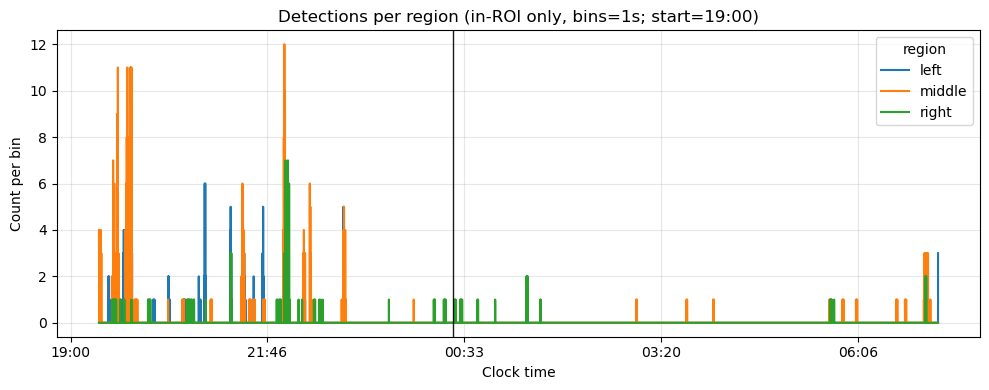

Saved figure to /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010067_2025Nov12_detections_in_roi_60s.png


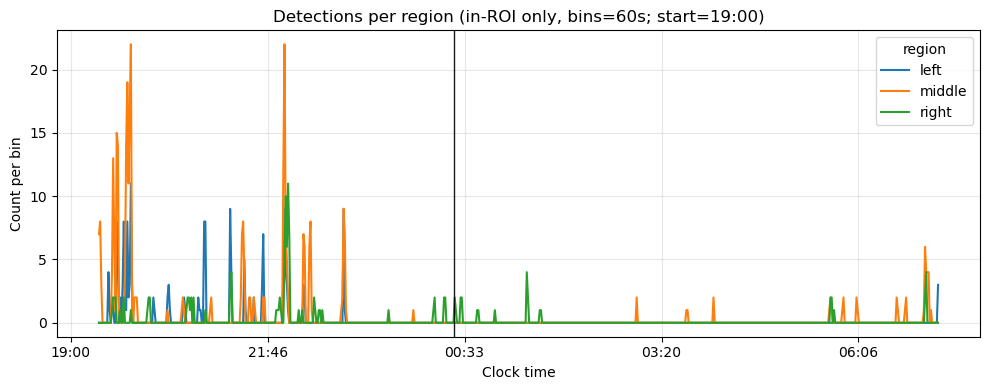

In [6]:
# Apply ROI to detections in-notebook and plot rates by region (exclude 'outside')
import io, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
from pathlib import Path

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'
VIDEO_DIR = ROOT / 'video'
CONFIG_DIR = DATA_DIR / 'config'

# Ensure figures directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Inputs
csv_path = DATA_DIR / 'processed' / f'{Path(video_name).stem}_streaks.csv'
roi_json_path = DATA_DIR / 'config' / f'{Path(video_name).stem}_rois.json'

# Sanity checks for required inputs
if not csv_path.exists():
    raise FileNotFoundError(f"Detections CSV not found: {csv_path}. Run the extraction cell first.")
if not roi_json_path.exists():
    available = sorted(p.name for p in CONFIG_DIR.glob('*_rois.json'))
    msg = [
        f"ROI JSON not found for {Path(video_name).stem} at {roi_json_path}.",
        "- Did you run the ROI selection cell and press ENTER to confirm?",
        f"- Expected filename: {Path(video_name).stem}_rois.json",
        f"- Available ROI files in {CONFIG_DIR}: {available if available else 'None found'}",
        "- If you want to reuse a different video's ROI, copy it to this stem or set video_name accordingly.",
    ]
    raise FileNotFoundError("\n".join(msg))

# Load detections (skip preamble)
with open(csv_path, 'r') as f:
    lines = f.readlines()
# find data header
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
print(f"Raw detections loaded: {len(df)} rows")

# Optional: filter persistent (long-lasting) contours BEFORE ROI mapping
try:
    enable_persistence_filter
except NameError:
    enable_persistence_filter = True
try:
    persistence_link_radius_px
except NameError:
    persistence_link_radius_px = 8.0   # link detections across consecutive frames within this pixel radius (scaled coords)
try:
    max_track_duration_s
except NameError:
    max_track_duration_s = 50.0       # drop tracks lasting longer than this many seconds

if enable_persistence_filter and not df.empty:
    print(f"Persistence filter ENABLED (radius={persistence_link_radius_px}, max_duration={max_track_duration_s}s)")
    df = df.sort_values(['frame']).reset_index(drop=True).copy()
    track_id_counter = -1
    assignments = np.full(len(df), -1, dtype=int)
    active = {}  # track_id -> {'last_cx','last_cy','last_frame','start_time','end_time','length'}
    frames = df['frame'].values
    times = df['time_s'].values
    cxs = df['cx'].values.astype(float)
    cys = df['cy'].values.astype(float)
    unique_frames = np.unique(frames)
    prev_frame = None
    for f in unique_frames:
        # close any track that skipped a frame
        if prev_frame is not None and f > prev_frame + 1:
            to_close = [tid for tid, t in active.items() if t['last_frame'] < f - 1]
            for tid in to_close:
                active.pop(tid, None)
        prev_frame = f
        idxs = np.where(frames == f)[0]
        used_tids = set()
        for i in idxs:
            cx, cy = cxs[i], cys[i]
            # candidates are active tracks updated on frame f-1 and within radius
            cand = []
            for tid, t in active.items():
                if t['last_frame'] == f - 1:
                    dx = cx - t['last_cx']
                    dy = cy - t['last_cy']
                    if (dx*dx + dy*dy) <= (persistence_link_radius_px * persistence_link_radius_px) and tid not in used_tids:
                        cand.append((tid, dx*dx + dy*dy))
            if cand:
                tid = min(cand, key=lambda x: x[1])[0]
                assignments[i] = tid
                t = active[tid]
                t['last_cx'] = cx; t['last_cy'] = cy; t['last_frame'] = f; t['end_time'] = times[i]; t['length'] += 1
                used_tids.add(tid)
            else:
                track_id_counter += 1
                tid = track_id_counter
                assignments[i] = tid
                active[tid] = {'last_cx': cx, 'last_cy': cy, 'last_frame': f, 'start_time': times[i], 'end_time': times[i], 'length': 1}
    # compute durations (seconds) per track
    df['track_id'] = assignments
    agg = df.groupby('track_id').agg(start_time=('time_s','min'), end_time=('time_s','max'), length=('frame','count')).reset_index()
    agg['duration_s'] = agg['end_time'] - agg['start_time']
    drop_ids = set(agg.loc[agg['duration_s'] > max_track_duration_s, 'track_id'].astype(int).tolist())
    if drop_ids:
        before = len(df)
        df = df[~df['track_id'].isin(drop_ids)].copy()
        after = len(df)
        print(f"Persistence filter: dropped {before-after} detections from {len(drop_ids)} long-lasting tracks (>{max_track_duration_s:.1f}s)")
    else:
        print("Persistence filter: no long-lasting tracks to drop.")
else:
    print("Persistence filter DISABLED")

# Determine detection coordinate scale: prefer CSV preamble, fallback to current analyze_scale/global
meta_vals = lines[1].strip().split(',') if len(lines) > 1 else []
scale_from_preamble = float(meta_vals[3]) if len(meta_vals) >= 4 else None
scale_from_global = float(globals().get('analyze_scale', 1.0))
scale_used = scale_from_preamble if scale_from_preamble is not None else scale_from_global
if scale_from_preamble is not None and 'analyze_scale' in globals():
    try:
        if abs(scale_from_preamble - float(analyze_scale)) > 1e-6:
            print(f"Warning: CSV preamble scale ({scale_from_preamble}) differs from current analyze_scale ({float(analyze_scale)}). Using preamble scale for ROI mapping.")
    except Exception:
        pass
print(f"ROI mapping scale = {scale_used} (source={'preamble' if scale_from_preamble is not None else 'global'})")

# Load ROI JSON (rects in original pixels)
with open(roi_json_path, 'r') as f:
    roi_cfg = json.load(f)
orig_w = int(roi_cfg['original_size']['width'])
orig_h = int(roi_cfg['original_size']['height'])
rects = roi_cfg['rects']

# Scale ROIs to detection coordinate space (scaled by scale_used)
scaled_rects = []
for r in rects:
    scaled_rects.append({
        'label': r['label'],
        'x': int(round(r['x'] * scale_used)),
        'y': int(round(r['y'] * scale_used)),
        'w': int(round(r['w'] * scale_used)),
        'h': int(round(r['h'] * scale_used)),
    })

# Assign region per detection
labels = []
for _, row in df.iterrows():
    cx, cy = float(row['cx']), float(row['cy'])
    lab = 'outside'
    for r in scaled_rects:
        if (cx >= r['x'] and cx < r['x'] + r['w'] and cy >= r['y'] and cy < r['y'] + r['h']):
            lab = r['label']
            break
    labels.append(lab)

df['region'] = labels

# Exclude 'outside' from totals and plots
df_in = df[df['region'] != 'outside'].copy()
print(f"Detections in ROI (post-filter if enabled): {len(df_in)}")

# Write filtered detections (persistence-filtered and in-ROI only) to a new CSV for downstream use
filtered_csv_path = DATA_DIR / 'processed' / f"{Path(video_name).stem}_streaks_in_roi_filtered.csv"
# Only write the viewer-required columns, in the original order, and include the original preamble for scale
required_cols = ['frame','time_s','region','cx','cy','area','bbox_x','bbox_y','bbox_w','bbox_h']
missing_cols = [c for c in required_cols if c not in df_in.columns]
if missing_cols:
    raise ValueError(f"Filtered DataFrame missing required columns: {missing_cols}")
df_out = df_in[required_cols].copy()
# Write preamble from the raw CSV so viewers can parse scale
with open(filtered_csv_path, 'w') as out_f:
    out_f.writelines(lines[:header_idx+1])  # includes metadata lines + header row
# Append data without header to keep the original header intact
df_out.to_csv(filtered_csv_path, index=False, header=False, mode='a')
print('Wrote filtered in-ROI detections to', filtered_csv_path)

# Adjustable clock start: set as HH:MM or HH:MM:SS (e.g., '19:00', '19:15', '19:00:30')
try:
    start_clock
except NameError:
    start_clock = '19:00'

def hhmm_formatter(x, pos):
    total_seconds = float(x) + _start_offset
    hours = int((total_seconds // 3600) % 24)
    minutes = int((total_seconds % 3600) // 60)
    return f"{hours:02d}:{minutes:02d}"

def _parse_start_clock(s: str) -> int:
    parts = s.split(':')
    if len(parts) < 2:
        raise ValueError("start_clock must be 'HH:MM' or 'HH:MM:SS'")
    h = int(parts[0]) % 24
    m = int(parts[1])
    sec = int(parts[2]) if len(parts) > 2 else 0
    return h * 3600 + m * 60 + sec

_start_offset = _parse_start_clock(start_clock)

# Moonrise offset relative to start_clock, formatted as 'H:MM' or 'HH:MM' (e.g., '0:00', '0:45', '1:30')
try:
    moonrise_offset
except NameError:
    moonrise_offset = '0:00'

def _parse_hhmm_offset(s: str) -> int:
    parts = s.split(':')
    if len(parts) < 2:
        raise ValueError("moonrise_offset must be 'H:MM' or 'HH:MM'")
    h = int(parts[0])
    m = int(parts[1])
    return h * 3600 + m * 60

_moonrise_x = _parse_hhmm_offset(moonrise_offset)

if df_in.empty:
    print("No in-ROI detections to plot.")
else:
    # Totals per region (in-ROI only)
    region_totals = df_in.groupby('region').size().sort_values(ascending=False)
    print('Totals per region (in-ROI only):\n', region_totals)

    # Plot bin counts at 1s and 60s (in-ROI only) with HH:MM x-axis
    for bin_seconds in (1.0, 60.0):
        dfb = df_in.copy()
        dfb['time_bin'] = (dfb['time_s'] // bin_seconds) * bin_seconds
        counts = dfb.groupby(['region', 'time_bin']).size().reset_index(name='count')
        pivot = counts.pivot(index='time_bin', columns='region', values='count').fillna(0)
        # Build a complete time index so missing bins are zero, not absent
        if not dfb.empty:
            start_bin = float(dfb['time_bin'].min())
            end_bin = float(dfb['time_bin'].max())
            all_bins = np.arange(start_bin, end_bin + bin_seconds, bin_seconds, dtype=float)
            pivot = pivot.reindex(all_bins, fill_value=0)
        fig, ax = plt.subplots(figsize=(10, 4))
        pivot.plot(ax=ax)
        # Thin black vertical line at moonrise (relative to start)
        ax.axvline(_moonrise_x, color='k', linewidth=1.0, alpha=0.9)
        ax.set_title(f'Detections per region (in-ROI only, bins={bin_seconds:.0f}s; start={start_clock})')
        ax.set_xlabel('Clock time')
        ax.set_ylabel('Count per bin')
        # Format x-axis ticks as HH:MM based on seconds since start
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(hhmm_formatter))
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        # Save figure with video stem in figures directory
        out_path = FIGURES_DIR / f"{Path(video_name).stem}_detections_in_roi_{int(bin_seconds)}s.png"
        plt.savefig(out_path, dpi=200)
        print('Saved figure to', out_path)
        plt.show()

In [7]:
# Final visual check: overlay ONLY in-ROI detections on the video (yellow)
# with labels of which LOI they are in
from pathlib import Path
import sys, subprocess

# Paths and inputs
ROOT = Path('..').resolve()
VIDEO_DIR = ROOT / 'video'
DATA_DIR = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
CONFIG_DIR = DATA_DIR / 'config'

try:
    video_name
except NameError:
    video_name = "GX010063.MP4"

# Prefer the filtered in-ROI, persistence-filtered CSV if available
filtered_csv = PROCESSED_DIR / f"{Path(video_name).stem}_streaks_in_roi_filtered.csv"
raw_csv = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
csv_path = filtered_csv if filtered_csv.exists() else raw_csv

roi_json_path = CONFIG_DIR / f"{Path(video_name).stem}_rois.json"
viewer_script = ROOT / 'scripts' / 'preview_contours_with_roi.py'

# Viewer options
line_thickness = 5
show_roi_edges = True   # draw ROI rectangles for context
start_frame = 0         # change to focus on a specific segment

# Determine the correct detection/display scale for the viewer
scale_for_viewer = None
try:
    scale_for_viewer = float(analyze_scale)
except NameError:
    scale_for_viewer = None
if scale_for_viewer is None:
    # Parse from CSV preamble (filtered now includes preamble; fallback to raw CSV if needed)
    import io
    try:
        with open(csv_path, 'r') as f:
            _lines = f.readlines()
        if len(_lines) > 1:
            _vals = _lines[1].strip().split(',')
            if len(_vals) >= 4:
                scale_for_viewer = float(_vals[3])
    except Exception:
        scale_for_viewer = None
if scale_for_viewer is None:
    # Last resort
    scale_for_viewer = 1.0

cmd = [
    sys.executable,
    str(viewer_script),
    '--video', str(VIDEO_DIR / video_name),
    '--csv', str(csv_path),
    '--roi-config', str(roi_json_path),
    '--line-thickness', str(line_thickness),
    '--scale', str(scale_for_viewer),
]

if show_roi_edges:
    cmd += ['--show-roi']

print('Using CSV:', csv_path)
print('Scale for viewer:', scale_for_viewer)
print('Command:', ' '.join(cmd))
print('Controls: SPACE play/pause, LEFT/RIGHT step, R toggle ROI, Q/ESC quit')
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Using CSV: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks_in_roi_filtered.csv
Scale for viewer: 0.5
Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/preview_contours_with_roi.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010067_2025Nov12.MP4 --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010067_2025Nov12_streaks_in_roi_filtered.csv --roi-config /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010067_2025Nov12_rois.json --line-thickness 5 --scale 0.5 --show-roi
Controls: SPACE play/pause, LEFT/RIGHT step, R toggle ROI, Q/ESC quit
Exit code: 0
Exit code: 0
